# **Laboratorio 11: Clasificación por Regresión Logística**

Departamento de Ingeniería Biomédica

Universidad de los Andes

**IBIO-2340:** Fundamentos de Machine Learning

**Nombres de los integrantes**


1.   Santiago Casasbuenas
2.   Juan Pablo Castro
3.   Ana Cristina Rodríguez

**Número del grupo**

9


# **Modelo de Regresión Logística**

Modelo de clasificación binaria que predice la probabilidad de que uno o más predictores pertenezca a la clase positiva (aquella codificada como 1 en el espacio de representación) utilizando una función logística (sigmoide) aplicada a una combinación lineal de las variables de entrada:

\begin{align*}
  P(y_{i}=1|x_{i}) = \frac{1}{1 + e^{-( w^Tx_{i}+b)}} 
\end{align*}

Donde $w$ son los coeficientes del plano (o *pesos*), $b$ el intercepto (o *bias*) y $x_{i}$ la observación asociada a la etiqueta $y_{i}$, así $x,w \in \mathbb{R}^n$ y $b \in \mathbb{R}$.

El objetivo del entrenamiento es determinar los valores óptimos de los parámetros $w$ y $b$ de modo que la forma funcional de la función sigmoide se ajuste lo mejor posible a las etiquetas reales en los datos de entrenamiento, dentro del paradigma de Machine Learning Supervisado. Conforme mejor sea el ajuste, más acertadas son las probabilidades predichas y mejor se da la clasificación.

*Nota:* Es importante aclarar que el plano $w^Tx+b = 0$ se conoce como **frontera de decisión** y existe en el espacio de representación. Esta frontera ajusta los datos para calcular la probabilidad de pertenencia a la clase positiva. La decisión final (la clase a la que pertenece cada instancia del conjunto de datos) depende de si esta probabilidad predicha supera un umbral predefinido (0.5 si las clases están balanceadas en el conjunto de entrenamiento).

**1. Fundamento teórico**

Supongamos un conjunto de $m$ observaciones:

\begin{align*}
   \{(x^{(1)},y^{(1)}), (x^{(2)},y^{(2)}), ... , (x^{(m)},y^{(m)})\}.
\end{align*}

Donde cada $x^{(i)}$ corresponde a un predictor y cada $y^{(i)}$ corresponde a una de las dos clases a la que pertenece dicho predictor. Cada clase será representada con los valores 1 y 0, que se conocen respectivamente como *clase positiva* y *clase negativa*. La probabilidad de que una instancia de estas observaciones pertenezca a la clase positiva esta dada por la distribución de la función logística:

\begin{align*}
   \hat{p} = \sigma(t) = \frac{1}{1 + e^{-t^{(i)}}} 
\end{align*}

Donde $\hat{p} \in [0,1]$ corresponde a la probabilidad predicha y $t^{(i)} \in \mathbb{R}$ se conoce como *score lineal* y corresponde a un ajuste lineal de los datos:

\begin{align*}
   t^{(i)} = b + w_{i}x^{(i)}
\end{align*}

Dada la probabilidad predicha para la clase positiva, la probabilidad de la clase negativa queda directamente determinada por la relación $1 - \hat{p}$. Finalmente el modelo determina la clase a la que pertenece la instancia $x^{(i)}$ de acuerdo al siguiente umbral:

\begin{align*}
   \hat{y} = \left\{
\begin{array}{l}
  0, \text{si} \; \hat{p} < 0.5 \\
  1, \text{si} \; \hat{p} \geq 0.5
\end{array}
\right.
\end{align*}

**Nota**: Debido a su comportamiento en forma de $S$ (acotada, suave y definida para todos los reales), la función logística hace parte las llamadas funciones *sigmoides*. Este grupo de funciones tienen un amplio uso dentro de algunos modelos de Deep Learning como funciones de activación.

**2. ¿Cómo se entrena el modelo ?**

Entrenar un modelo de Regresión Logística implica determinar los valores óptimos de los parámetros $w_1, b$ que ajusten de la mejor forma las predicciones probabilísticas, $\hat{y}$, a las clases reales de los datos observados, $y$. Para ello, como ya lo estudiamos en el modelo de Regresión Lineal, es necesario definir una **función de pérdida** adecuada, cuya optimización reduzca el error entre la predicción $\hat{y}$ y el valor real $y$. Para el caso de un problema de clasificación, esta función de pérdida se conoce como **log loss** o **binary cross-entropy** y se define como sigue:

$$
L(w,b) = - \frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)}ln(\hat{p}^{(i)}) + (1-y^{(i)})ln(1 - \hat{p}^{(i)}) \right]
$$

Siendo $m$ el número de observaciones, $\hat{p}^{(i)}$ la predicción de la probabilidad y $y^{(i)}$ la etiqueta real. Veamos cómo actua esta función de pérdida para una sola observación:

1. Supongamos que la clase verdadera, la etiqueta, es la clase positiva $y_{i}=1$ para $x_{i}$, de modo que la función de pérdida se reduce a la expresión $L= -ln( \hat{p} )$. Si el algortimo predice una probabilidad muy baja de que $x_{i}$ pertenezca a esta clase, es decir $\hat{p} \rightarrow 0$, de modo que $L= -ln(\hat{p}) \rightarrow  \infty $ entonces la función de pérdida se hace muy grande *indicando un error en la predicción*. Si por el contrario, el algoritmo predice una probabilidad muy alta de que $x_{i}$ pertenezca a esta clase, es decir $\hat{p} \rightarrow 1$, entonces $L= -ln(\hat{p}) \rightarrow  0 $ y por lo tanto la función de pérdida se hace muy pequeña o nula, *indicando una predicción precisa*.

2. Para la clase negativa se opera de forma similar. Supongamos que la clase verdadera, la etiqueta, es la clase negativa $y_{i}=0$ para $x_{i}$, de modo que la función de pérdida se reduce a la expresión $L= -ln( 1 - \hat{p} )$. Si el algoritmo predice una probabilidad muy baja de que $x_{i}$ pertenezca a esta clase, es decir $1 - \hat{p} \rightarrow 0$, de modo que $L= -ln(1 - \hat{p}) \rightarrow  \infty $ entonces la función de pérdida se hace muy grande. Si por el contrario, el algoritmo predice una probabilidad muy alta de que $x_{i}$ pertenezca a esta clase, es decir $1 - \hat{p} \rightarrow 1$, entonces $L= -ln(1 - \hat{p}) \rightarrow  0 $ y por lo tanto la función de pérdida se hace muy pequeña o nula.

Así, *la función de pérdida aumenta o disminuye según la precisión en la predicción de la probabilidad y se ajusta al comportamiento que esperamos dentro del paradigma del ML Supervisado*. Ahora, ya que entendemos el funcionamiento de la función de pérdida, basta encontrar los parámetros óptimos $w,b$ que mejor ajustan los datos. Para ello basta con minimizar la función de pérdida respecto a estos parámetros:

$$
  \min_{w,b\in\mathbb{R}} L(w,b).
$$

Este problema es convexo así que pueden usarse algoritmos de optimización numérica para hallar el minimizador y podemos garantizar que, bajo las condiciones adecuadas de convergencia, este minimizador corresponde al mínimo global. Uno de los algoritmos más utilizados para resolver este problema es el **Método de Newton**, que estudiamos en laboratorios anteriores. Una vez se conocen los valores óptimos de $w$ y $b$, el modelo de Regresión Logística entrenado puede usarse para predecir la clase a la que pertenecen datos no vistos. 

# **Contexto del problema**

Uno de los tipos de cáncer más común entre la población femenina es el cáncer de seno. Éste ocurre cuando las células normales mutan y se transforman en células cancerígenas. Esta transformación puede ser evaluada a través de procedimientos en los que se extraen muestras de tejido y se observan bajo el microscopio. Se ha mostrado que en etapas tempranas el núcleo de las células provenientes de los tumores cambia su morfología, permitiendo predecir el desarrollo del cáncer (Narasimha et al., 2013).

En este laboratorio vamos a entrenar un modelo de Regresión Logística para determinar si las células provenientes de un tumor están en proceso de mutación carcinogénica o no, es decir, implementaremos un modelo de clasificación, una tarea que hace parte del paradigma de Aprendizaje Supervisado en Machine Learning.

Para entrenar el modelo usaremos una base de datos que consta de 469 muestras obtenidas de dos tipos de pacientes: mujeres que desarrollaron cáncer de seno y aquellas que no. Clasificaremos dicha aparición a partir de dos características que se extraen de las imágenes: el **radio promedio** y el **índice de suavidad** (_smoothness index_) de los núcleos de las células. Esta última medida hace referencia a un índice de variación local del radio en un mismo núcleo: conforme más pequeño sea el índice de suavidad, más redondo será el núcleo. Estas medidas se toman a partir de una imagen del tejido, como se muestra en la Figura 1.

<center> Figura 1. Muestras de núcleos celulares de biopsias de tumores de seno, los núcleos pequeños y redondos proceden de muestras no-cancerígenas (Narasimha et al., 2013). </center>

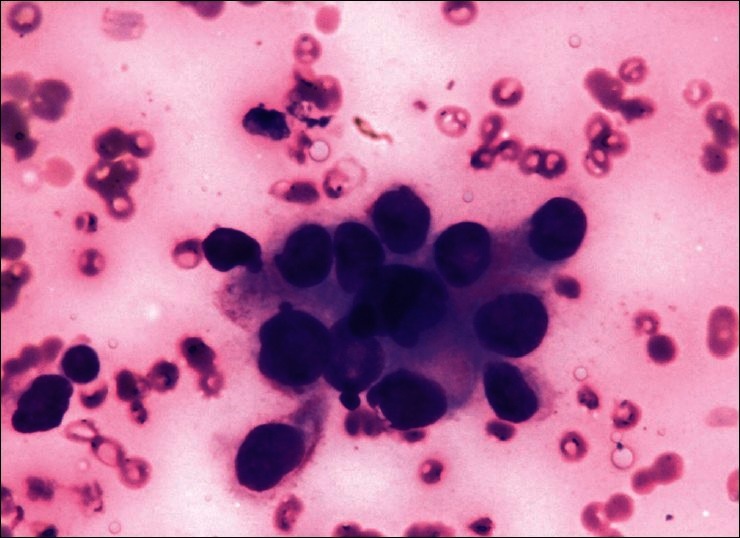

> Narasimha, A., Vasavi, B., & Kumar, H. M. (2013). Significance of nuclear morphometry in benign and malignant breast aspirates. _International Journal of Applied and Basic Medical Research_, 3(1), 22.


# **Ejercicios**

1. Importe los datos del archivo *Breast_Cancer_Train.csv*. Este archivo se compone de tres columnas: las dos primeras corresponden a los valores del radio promedio y del índice de suavidad medidos en las muestras y la tercera columna, de encabezado _"Pronostic"_, corresponde al pronóstico de estas:

- $1$ si la muestra proviene de un tumor maligno.
- $0$ si la muestra proviene de un tumor benigno.

Haga un gráfico de dispersión entre el radio promedio y el índice de suavidad agregando el pronóstico como barra de color. Analice la gráfica resultante.

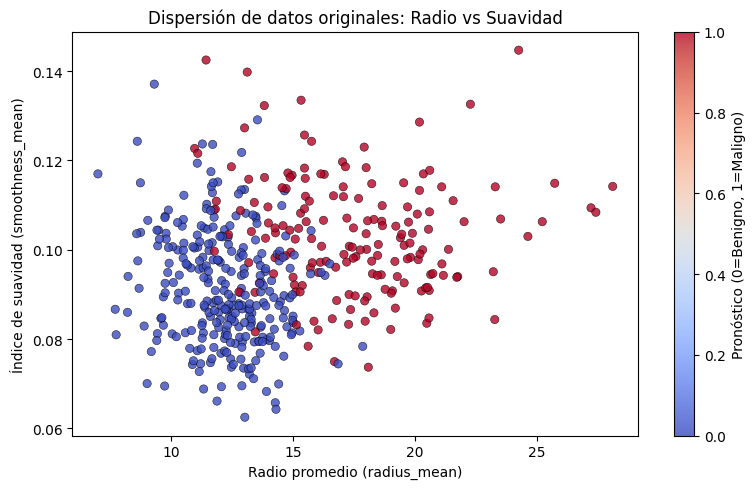

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos de entrenamiento
df_train = pd.read_csv('Breast_Cancer_Train.csv')

# Extraer características y etiquetas
radius = df_train['radius_mean'].values
smoothness = df_train['smoothness_mean'].values
labels = df_train['pronostic'].values

# Gráfico de dispersión: radius vs smoothness coloreado por pronóstico
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(radius, smoothness, c=labels, cmap='coolwarm', edgecolors='k', linewidths=0.4, alpha=0.8)
plt.colorbar(scatter, ax=ax, label='Pronóstico (0=Benigno, 1=Maligno)')
ax.set_xlabel('Radio promedio (radius_mean)')
ax.set_ylabel('Índice de suavidad (smoothness_mean)')
ax.set_title('Dispersión de datos originales: Radio vs Suavidad')
plt.tight_layout()
plt.show()


2. Note que los valores de la característica *smoothness* se encuentran en el intervalo $[0.06215, 0.1447]$, mientras que los valores de la característica *radius* yacen en el intervalo  $[7.691, 28.11]$. Esta diferencia de escala entre los dos predictores afecta directamente la estimación de los parámetros $w$ y $b$ que definen la frontera de decisión  obligando al ajuste a dar prioridad a una característica sobre la otra. Una forma de atender esta dificultad consiste en estandarizar los datos de modo que se anule la diferencia de escala. Para ello podemos usar la función `StandardScaler` de la librería `sklearn` de la siguiente forma:

```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
```
Donde `X` es la matriz que condensa las observaciones dentro del modelo lineal que ajusta la frontera de decisión:

\begin{align*}
  X =
  \begin{bmatrix}
    x_1^{(1)} & x_2^{(1)} & ⋯ & x_n^{(1)} \\
    x_1^{(2)} & x_2^{(2)} & ⋯ & x_n^{(2)} \\
    \vdots & \vdots & \ddots & \vdots\\
    x_1^{(m)} & x_2^{(m)} & ⋯ & x_n^{(m)}
  \end{bmatrix}
\end{align*}

Donde $x_i^{(j)}$ es la observación $j$ para la característica $i$. De modo que, 

$$
X \theta + b = 0
$$

Con $\theta = [w_1 w_2 ... w_n]^T$

Implemente una función que reciba los arreglos de las observaciones y retorne el arreglo con los datos estandarizados. Luego repita el gráfico del punto anterior pero considerando ahora los datos estandarizados.

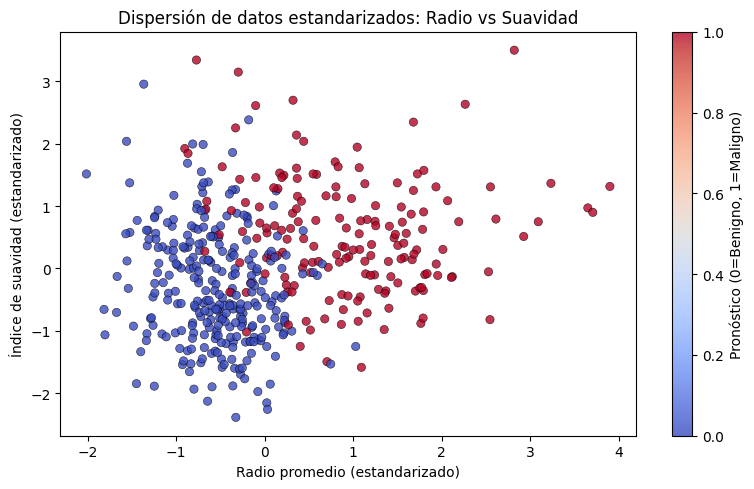

In [20]:
from sklearn.preprocessing import StandardScaler

def estandarizar(X):
    """Estandariza las columnas de X con media 0 y desviación estándar 1."""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled, scaler  # también retornamos el scaler para usarlo en prueba

# Matriz de características: [radius, smoothness]
X_train = np.column_stack([radius, smoothness])

# Estandarizar datos de entrenamiento
X_scaled, scaler_breast = estandarizar(X_train)

# Gráfico de dispersión con datos estandarizados
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels,
                     cmap='coolwarm', edgecolors='k', linewidths=0.4, alpha=0.8)
plt.colorbar(scatter, ax=ax, label='Pronóstico (0=Benigno, 1=Maligno)')
ax.set_xlabel('Radio promedio (estandarizado)')
ax.set_ylabel('Índice de suavidad (estandarizado)')
ax.set_title('Dispersión de datos estandarizados: Radio vs Suavidad')
plt.tight_layout()
plt.show()


3. Para entrenar un modelo de Clasificación por Regresión Logística podemos utilizar el método `.fit()`  del objeto `LogisticRegression()` de la librería `sklearn.linear_model` de la siguiente forma:

```
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_scaled, y)
```

Donde `y` es el vector de etiquetas,

\begin{align*}
  y = \left[ y^{(1)}, y^{(2)}, ..., y^{(m)}\right]^T
\end{align*}

Una vez entrenado el modelo se pueden obtener los parámetros óptimos $w$ y $b$ estimados utilizando los atributos `.coef_` e `.intercept_` del objeto `model()`:

```
w = model.coef_.flatten()
b = model.intercept_

```
Implemente una función que tome por argumentos los datos estandarizados y el arreglo con las etiquetas, y retorne un diccionario con el modelo entrenado y los parámetros $w$ y $b$.

In [21]:
from sklearn.linear_model import LogisticRegression

def entrenar_modelo(X_scaled, y):
    """Entrena un modelo de Regresión Logística y retorna modelo y parámetros."""    
    model = LogisticRegression()
    model.fit(X_scaled, y)

    w = model.coef_.flatten()   # pesos de cada característica
    b = model.intercept_        # término de sesgo (bias)

    return {'model': model, 'w': w, 'b': b}

# Entrenar sobre datos estandarizados de cáncer de seno
resultado_breast = entrenar_modelo(X_scaled, labels)
print("Parámetros w:", resultado_breast['w'])
print("Parámetro b:", resultado_breast['b'])


Parámetros w: [3.60420497 1.37867832]
Parámetro b: [-0.73345291]


4. Grafique nuevamente la dispersión de los datos estandarizados pero incluya ahora la frontera de decisión que definen los parámetros óptimos $w$ y $b$.

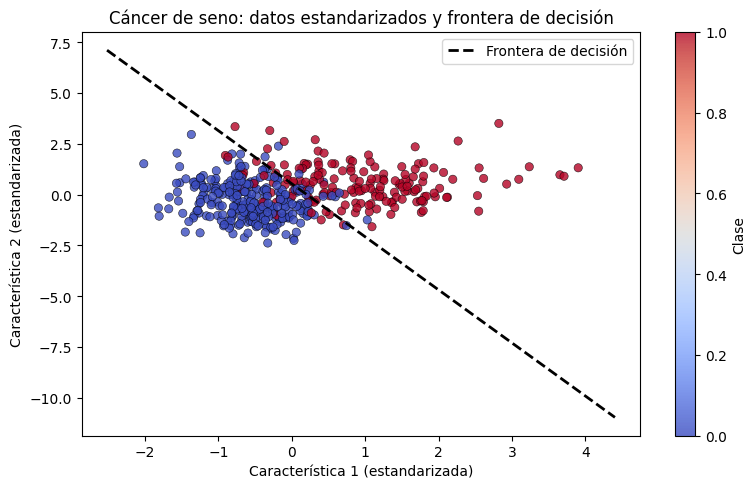

In [22]:
def graficar_frontera(X_scaled, y, w, b, titulo='Frontera de decisión'):
    """Grafica datos estandarizados junto con la frontera de decisión lineal."""    
    fig, ax = plt.subplots(figsize=(8, 5))
    scatter = ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y,
                         cmap='coolwarm', edgecolors='k', linewidths=0.4, alpha=0.8)
    plt.colorbar(scatter, ax=ax, label='Clase')

    # La frontera satisface: w[0]*x1 + w[1]*x2 + b = 0  =>  x2 = -(w[0]*x1 + b) / w[1]
    x1 = np.linspace(X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5, 200)
    x2 = -(w[0] * x1 + b) / w[1]
    ax.plot(x1, x2, 'k--', linewidth=2, label='Frontera de decisión')

    ax.set_xlabel('Característica 1 (estandarizada)')
    ax.set_ylabel('Característica 2 (estandarizada)')
    ax.set_title(titulo)
    ax.legend()
    plt.tight_layout()
    plt.show()

# Visualizar frontera para datos de cáncer de seno
graficar_frontera(X_scaled, labels,
                  resultado_breast['w'], resultado_breast['b'],
                  titulo='Cáncer de seno: datos estandarizados y frontera de decisión')


5. Para evaluar el rendimiento del modelo utilizamos una métrica (score) sobre datos no vistos durante el proceso de entrenamiento. De acuerdo al valor de la métrica, podemos establecer la generalidad y robustez del modelo. Una métrica usual en la tarea de clasificación consiste en calcular el porcentaje de datos correctamente clasificados con respecto al total de datos.

Implemente una función que utilice el modelo que ya entrenó y uselo para evaluar su rendimiento en los datos de prueba tomados del archivo *Breast_Cancer_Test.csv* (la función debe tomar por argumentos este modelo, la matriz H con los nuevos datos y las etiquetas de los nuevos datos). Finalmente retorne el porcentaje de datos bien clasificados con respecto al total de datos. Recuerde que el modelo se entrenó utilizando los datos estandarizados, por lo cual es necesario utilizar el estandarizador ajustado en los datos de entrenamiento para escalar los datos de prueba. **Hint**: Consulte en la documentación de Scikit-Learn cómo se utiliza el método `predict()` del objeto `LogisticRegression()`. 

In [23]:
def evaluar_modelo(resultado, scaler, X_nuevo, y_nuevo):
    """Estandariza nuevos datos y calcula porcentaje de aciertos del modelo."""    # Escalar usando el scaler ajustado en entrenamiento
    X_nuevo_scaled = scaler.transform(X_nuevo)

    model = resultado['model']
    y_pred = model.predict(X_nuevo_scaled)  # predicciones del modelo

    # Porcentaje de muestras correctamente clasificadas
    accuracy = np.mean(y_pred == y_nuevo) * 100
    return accuracy

# Cargar datos de prueba del cáncer de seno
df_test = pd.read_csv('Breast_Cancer_Test.csv')
X_test_breast = df_test[['radius_mean', 'smoothness_mean']].values
y_test_breast = df_test['pronostic'].values

acc_breast = evaluar_modelo(resultado_breast, scaler_breast, X_test_breast, y_test_breast)
print(f"Precisión en prueba (cáncer de seno): {acc_breast:.2f}%")


Precisión en prueba (cáncer de seno): 88.60%


6. En general, la frontera de decisión no tiene un comportamiento lineal tan marcado como el que observamos en los datos anteriores, sino que sigue comportamientos más complejos. Para analizar esto, importe los datos del archivo *classification_train.txt* en donde las dos primeras columnas $(X,Y)$ corresponden a las observaciones y la tercera columna ($Z$) a las etiquetas. Luego, haga un gráfico de dispersión entre $X$ y $Y$ agregando la etiqueta $Z$ como barra de color.

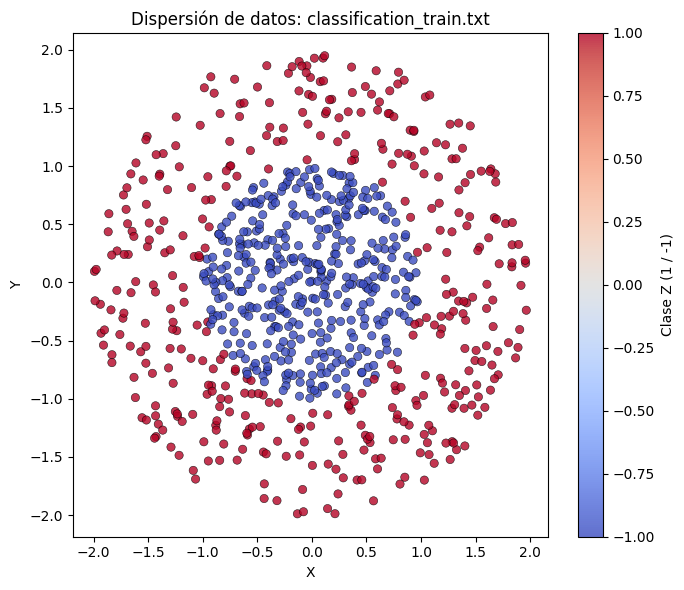

In [24]:
# Cargar datos de clasificación con frontera no lineal
df_cls = pd.read_csv('classification_train.txt', sep=r'\s+')

X_cls = df_cls[['X', 'Y']].values
y_cls = df_cls['Z'].values

# Gráfico de dispersión de los nuevos datos
fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(X_cls[:, 0], X_cls[:, 1], c=y_cls,
                     cmap='coolwarm', edgecolors='k', linewidths=0.4, alpha=0.8)
plt.colorbar(scatter, ax=ax, label='Clase Z (1 / -1)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Dispersión de datos: classification_train.txt')
plt.tight_layout()
plt.show()


7. Utilice las funciones que implementó anteriormente para estandarizar y entrenar el modelo de clasificación con estos nuevos datos. Luego, grafique nuevamente la dispersión de estos datos estandarizados pero incluya ahora la frontera de decisión que definen los parámetros óptimos $w$ y $b$.

Parámetros w: [ 0.08164796 -0.13908234]
Parámetro b: [1.98137987e-05]


/Users/santiagocasasbuenasalarcon/Documents/universidad/Fundamentos ML/LabsML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/santiagocasasbuenasalarcon/Documents/universidad/Fundamentos ML/LabsML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/santiagocasasbuenasalarcon/Documents/universidad/Fundamentos ML/LabsML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept


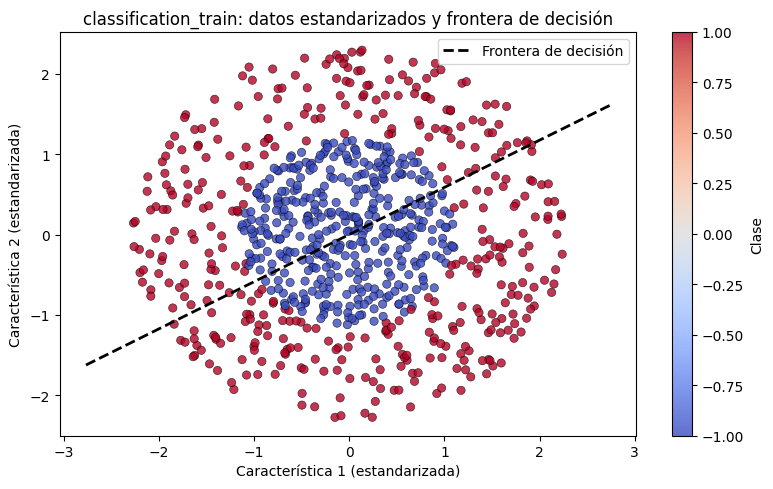

In [25]:
# Estandarizar los datos de clasificación
X_cls_scaled, scaler_cls = estandarizar(X_cls)

# Entrenar modelo logístico con datos estandarizados
resultado_cls = entrenar_modelo(X_cls_scaled, y_cls)
print("Parámetros w:", resultado_cls['w'])
print("Parámetro b:", resultado_cls['b'])

# Visualizar frontera de decisión (notar que puede no separar bien los datos circulares)
graficar_frontera(X_cls_scaled, y_cls,
                  resultado_cls['w'], resultado_cls['b'],
                  titulo='classification_train: datos estandarizados y frontera de decisión')


8. Utilice ahora la función que calcula la métrica que implementó anteriormente para evaluar el rendimiento de los datos nuevos, en el conjunto de prueba importando los datos del archivo *classification_test.txt*.

In [26]:
# Cargar datos de prueba del archivo de clasificación
df_cls_test = pd.read_csv('classification_test.txt', sep=r'\s+')
X_cls_test = df_cls_test[['X', 'Y']].values
y_cls_test = df_cls_test['Z'].values

# Evaluar modelo (entrenado en espacio original) sobre datos de prueba
acc_cls = evaluar_modelo(resultado_cls, scaler_cls, X_cls_test, y_cls_test)
print(f"Precisión en prueba (classification_test.txt): {acc_cls:.2f}%")


Precisión en prueba (classification_test.txt): 52.00%


9. Encuentre una transformación que separe linealmente los datos del archivo *classification_train.txt*. Grafique la distribución de los datos en el nuevo espacio de características y entrene un modelo de clasificación con los datos transformados. Finalmente, utilice la métrica implementada anteriormente para evaluar el rendimiento del modelo en el conjunto de prueba.

*Hint:* Es necesario aplicar la transformación sobre los datos de prueba antes de evaluarlos en el modelo.

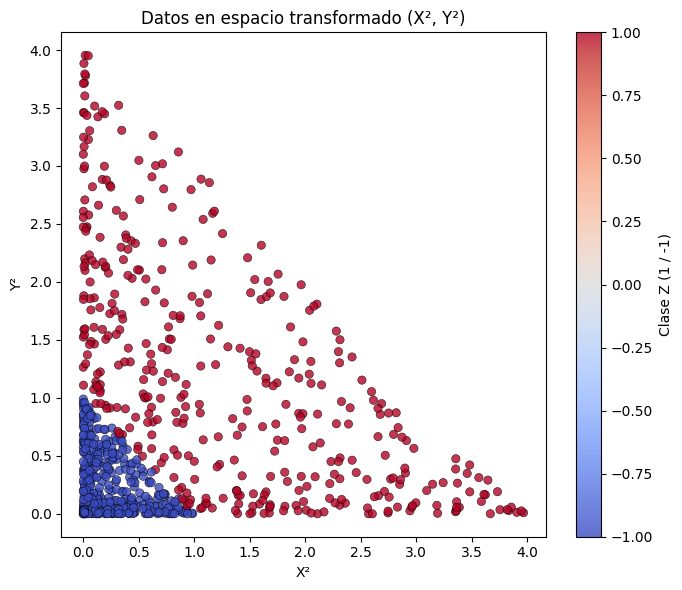

/Users/santiagocasasbuenasalarcon/Documents/universidad/Fundamentos ML/LabsML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/santiagocasasbuenasalarcon/Documents/universidad/Fundamentos ML/LabsML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/santiagocasasbuenasalarcon/Documents/universidad/Fundamentos ML/LabsML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept


Parámetros w: [5.68517274 5.26065188]
Parámetro b: [2.32789332]


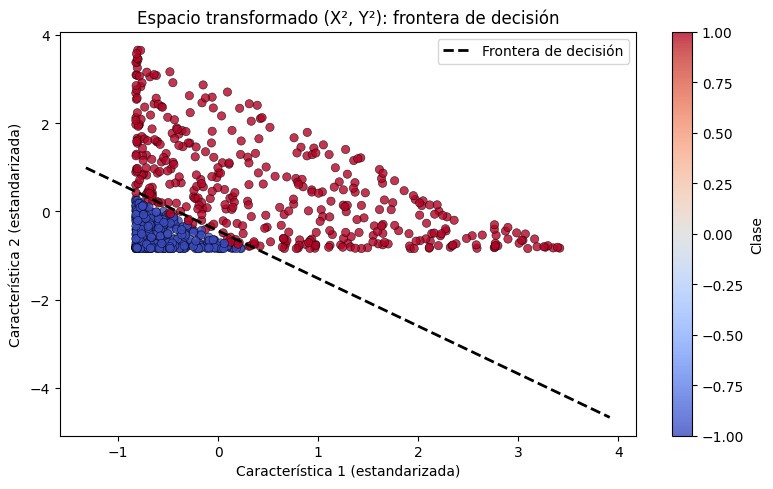


Precisión en prueba con transformación (X², Y²): 99.50%


In [27]:
# Los datos de classification_train.txt forman dos regiones concéntricas:
#   Clase -1: X² + Y² < 1  (círculo interior)
#   Clase  1: X² + Y² > 1  (anillo exterior)
#
# La frontera X² + Y² = 1 es una circunferencia no lineal en (X,Y), pero
# al transformar a (X², Y²) la frontera se convierte en la línea X² + Y² = 1,
# que es lineal en el nuevo espacio.

def transformar(X):
    """Eleva al cuadrado cada característica para linealizar la frontera circular."""    
    return np.column_stack([X[:, 0]**2, X[:, 1]**2])

# Aplicar transformación a datos de entrenamiento
X_cls_transf = transformar(X_cls)

# Gráfico en el nuevo espacio de características
fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(X_cls_transf[:, 0], X_cls_transf[:, 1], c=y_cls,
                     cmap='coolwarm', edgecolors='k', linewidths=0.4, alpha=0.8)
plt.colorbar(scatter, ax=ax, label='Clase Z (1 / -1)')
ax.set_xlabel('X²')
ax.set_ylabel('Y²')
ax.set_title('Datos en espacio transformado (X², Y²)')
plt.tight_layout()
plt.show()

# Estandarizar y entrenar modelo en el espacio transformado
X_cls_transf_scaled, scaler_transf = estandarizar(X_cls_transf)
resultado_transf = entrenar_modelo(X_cls_transf_scaled, y_cls)
print("Parámetros w:", resultado_transf['w'])
print("Parámetro b:", resultado_transf['b'])

# Visualizar frontera de decisión en espacio transformado
graficar_frontera(X_cls_transf_scaled, y_cls,
                  resultado_transf['w'], resultado_transf['b'],
                  titulo='Espacio transformado (X², Y²): frontera de decisión')

# Evaluar sobre datos de prueba con la misma transformación aplicada
X_cls_test_transf = transformar(X_cls_test)
acc_transf = evaluar_modelo(resultado_transf, scaler_transf, X_cls_test_transf, y_cls_test)
print(f"\nPrecisión en prueba con transformación (X², Y²): {acc_transf:.2f}%")


10. Responda las siguientes preguntas:

- Compare el gráfico de observaciones antes y después de estandarizar los datos, ¿cómo se estandarizan los datos?. **Hint**: Revise la documentación de la función utilizada para estandarizar.
- Tomando como referencia el gráfico de dispersión que incluye la frontera de decisión para los datos de cancer de seno, ¿por dónde se trazó ésta recta?, ¿podemos decir que minimiza las distancias entre los puntos?
- Fíjese que una forma *a priori* de evaluar el rendimiento del modelo de Clasificación puede ser la revisión de la frontera de decisión: conforme mejor se separen las dos clases en este espacio de características mejor será la predicción del modelo. Teniendo en cuenta el comportamiento de la frontera de decisión en los datos sobre el cáncer de seno y el comportamiento que propone para los datos nuevos en la respuesta anterior, ¿cómo podríamos determinar desde este punto de vista gráfico si un dato está bien o mal clasificado?

**10. Respuestas**

**¿Cómo se estandarizan los datos?**

La función `StandardScaler` de scikit-learn transforma cada característica $x_i$ de la siguiente manera:

$$x_i' = \frac{x_i - \mu_i}{\sigma_i}$$

donde $\mu_i$ es la media y $\sigma_i$ es la desviación estándar de la característica $i$ calculadas sobre el conjunto de entrenamiento. El resultado es que cada característica queda con media $0$ y desviación estándar $1$, eliminando las diferencias de escala entre predictores. Al comparar ambos gráficos, se puede observar que la forma relativa de la nube de puntos se preserva, pero los ejes cambian de sus unidades originales (e.g., mm para el radio y valores en $[0.06, 0.14]$ para la suavidad) a una escala centrada en cero con valores típicamente en $[-3, 3]$.

---

**¿Por dónde se trazó la frontera de decisión para los datos de cáncer de seno?**

La frontera de decisión se trazó por la zona donde la probabilidad predicha de pertenecer a la clase maligna es exactamente $0.5$, es decir, donde $w^T x + b = 0$. Visualmente, esta recta divide el espacio de características estandarizadas de modo que los tumores malignos ($y=1$) quedan mayormente de un lado y los benignos ($y=0$) del otro. La regresión logística **no minimiza directamente las distancias entre los puntos y la recta**; en cambio, maximiza la verosimilitud (likelihood) de las etiquetas observadas, lo que equivale a minimizar la función de pérdida de entropía cruzada. Por eso la frontera no necesariamente equidista de los puntos de cada clase.

---

**¿Cómo determinamos gráficamente si un dato está bien o mal clasificado?**

Una vez trazada la frontera de decisión en el espacio de características, un dato está **bien clasificado** si se encuentra en el semiplano correcto: los puntos de clase $1$ deben estar en el lado donde $w^T x + b > 0$ y los de clase $0$ (o $-1$) en el lado donde $w^T x + b < 0$. Un dato está **mal clasificado** si aparece en el semiplano opuesto al que le corresponde según su etiqueta. Cuanto más alejado esté del lado correcto, más confianza tiene el modelo en esa predicción errónea. Para los datos de `classification_train.txt`, la frontera lineal en el espacio original clasifica muy pobremente porque las clases forman anillos concéntricos; la transformación $(X, Y) \to (X^2, Y^2)$ logra que las clases sean linealmente separables y la frontera separa correctamente casi todos los puntos.
